# 05 – Modelagem Preditiva (Machine Learning)
**Objetivo:** Treinar, otimizar e avaliar modelos de classificação para prever o desfecho de óbito hospitalar (indicador_obito) em pacientes internados por IAM. Faremos a comparação entre modelos lineares e baseados em árvores, seguidos de análise de interpretabilidade.

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Interpretability
import shap

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

/home/carolina/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carregamento e Pré-processamento
Carregaremos a base reduzida (saída do notebook 03). Faremos o tratamento de variáveis categóricas (One-Hot Encoding) e a divisão em Treino/Teste.

In [2]:
DATA_PATH = Path('../data/processed/base_modelagem_reduzida.csv')
df = pd.read_csv(DATA_PATH, low_memory=False)

# Garantir tipo do target
df['indicador_obito'] = df['indicador_obito'].astype(int)

# Separar X e y
X = df.drop(columns=['indicador_obito'])
y = df['indicador_obito']

# One-Hot Encoding para categóricas
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# XGBoost e LightGBM não gostam de caracteres especiais nas colunas (como <, > ou [, ])
X_encoded.columns = [re.sub(r'[\[\]<>\s]', '_', col) for col in X_encoded.columns]

# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")

Treino: (39181, 149)
Teste:  (9796, 149)


## 2. Tratamento de Desbalanceamento & Baseline
A classe de óbitos é minoritária. Os algoritmos baseados em árvore (XGBoost/LightGBM) possuem parâmetros como `scale_pos_weight` ou `is_unbalance` para lidar com isso nativamente. Para o baseline (Regressão Logística), usaremos `class_weight='balanced'`.

In [3]:
# O Baseline (Logistic Regression) não aceita valores nulos, então vamos imputar a mediana.
# Modelos baseados em árvore (XGBoost/LightGBM) lidam com nulos nativamente.

baseline_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_lr = baseline_pipeline.predict(X_test)
y_prob_lr = baseline_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (Baseline) ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

# Para plotar a curva ROC depois, guardaremos a referência do modelo treinado
lr_model = baseline_pipeline

=== Logistic Regression (Baseline) ===
ROC-AUC: 0.8024
              precision    recall  f1-score   support

           0       0.97      0.75      0.85      9094
           1       0.18      0.70      0.29       702

    accuracy                           0.75      9796
   macro avg       0.57      0.73      0.57      9796
weighted avg       0.91      0.75      0.81      9796



## 3. Modelos Avançados (Tree-based)
Treinamento de XGBoost e LightGBM, que geralmente perforam melhor em dados tabulares sem necessidade de scaling rigoroso.

In [4]:
# Cálculo do peso para lidar com classes desbalanceadas (Altas / Óbitos)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Peso aplicado à classe minoritária: {scale_pos_weight:.2f}\n")

# --- XGBoost ---
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

# --- LightGBM ---
lgb_model = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42
)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}")
print(classification_report(y_test, y_pred_lgb))

Peso aplicado à classe minoritária: 12.95



=== XGBoost ===
ROC-AUC: 0.8746
              precision    recall  f1-score   support

           0       0.98      0.83      0.90      9094
           1       0.26      0.74      0.38       702

    accuracy                           0.83      9796
   macro avg       0.62      0.79      0.64      9796
weighted avg       0.93      0.83      0.86      9796

[LightGBM] [Info] Number of positive: 2809, number of negative: 36372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002287 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2553
[LightGBM] [Info] Number of data points in the train set: 39181, number of used features: 140
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

## 4. Avaliação e Comparação de Modelos
Plotar a Curva ROC comparando os modelos e visualizar as matrizes de confusão.

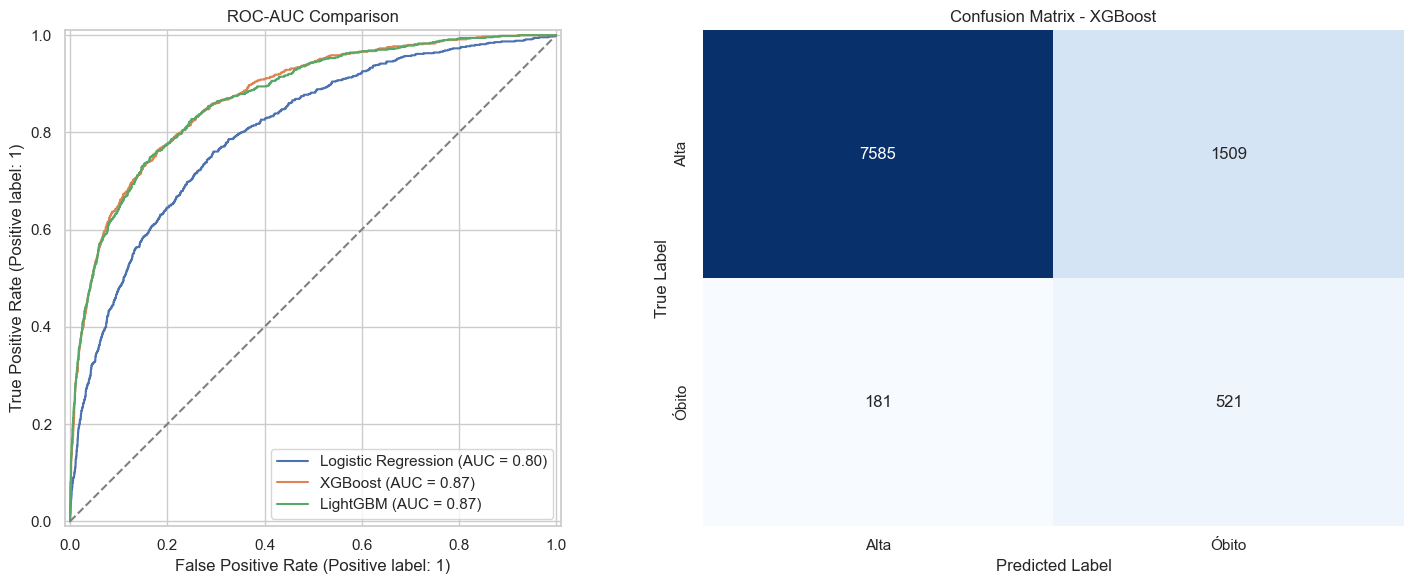

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Curvas ROC
RocCurveDisplay.from_estimator(lr_model, X_test, y_test, name='Logistic Regression', ax=axes[0])
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test, name='XGBoost', ax=axes[0])
RocCurveDisplay.from_estimator(lgb_model, X_test, y_test, name='LightGBM', ax=axes[0])
axes[0].set_title('ROC-AUC Comparison')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')

# Matriz de Confusão do melhor modelo (XGBoost)
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix - XGBoost')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_xticklabels(['Alta', 'Óbito'])
axes[1].set_yticklabels(['Alta', 'Óbito'])

plt.tight_layout()
plt.show()

## 5. Interpretabilidade (SHAP)
Extrair o SHAP summary plot do melhor modelo para entender quais features mais contribuem para o risco de óbito.

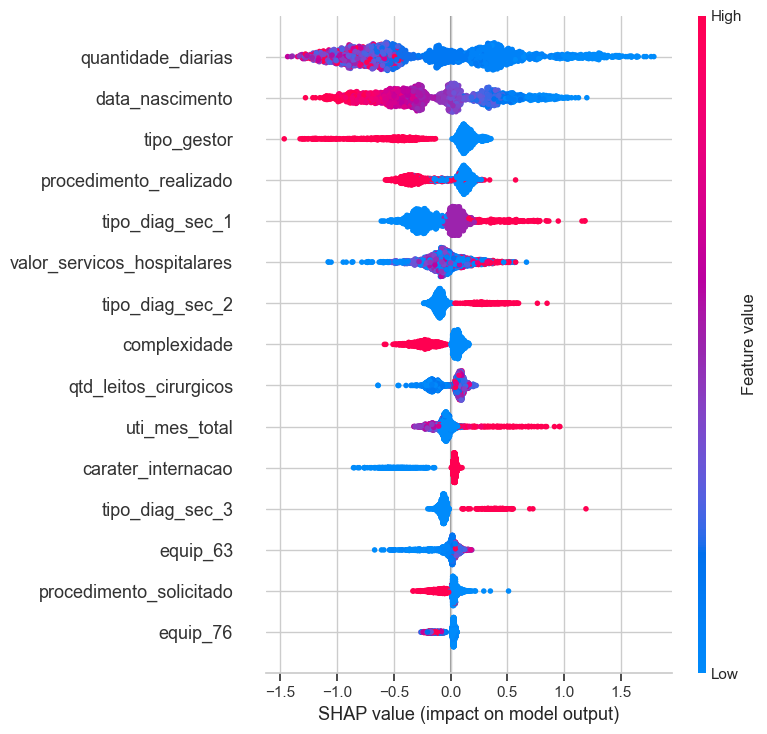

In [6]:
# O SHAP explica o impacto de cada variável na predição do XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Para não demorar muito, pegamos uma amostra do conjunto de teste
X_shap = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_shap)

# O Summary Plot mostra a importância das variáveis e a direção do efeito
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=15)
plt.show()